EJERCICIO1_DESCRIPTIVO

OUTPUTS:

* ej1_descriptivo.csv: Tabla de estadísticos descriptivos de todas las variables numéricas
(pandas describe)

* ej1_histogramas.png: Histogramas

* ej1_boxplots.png: Boxplots de la variable objetivo por cada variable categórica

* ej1_heatmap_correlacion.png: Mapa de calor de la matriz de correlaciones

* ej1_categoricas.png: Gráficos de frecuencia de las variables categóricas


In [462]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data\\anthropometric_2003_2023.csv")
df.head(3)

,Year,Gender,Age,1.Body Weight (kg),2.Stature height (cm),3.The height of the root of the nose in standing (cm),4.Height of shoulders in standing position (cm),5.Height of the elbow in standing position (cm),6.The height of the tip of the 3rd finger in standing position (cm),7.Arm's reach in standing position (cm),...,16.Knee height in sitting position (cm),17.Arm's reach in sitting position (cm),18.The length of the forearm and hand at the elbow bend (cm),19.Thigh length in sitting position at knee bend (cm),20.Leg length when sitting forward (cm),21.Arm's reach in sitting position (cm),22.Palm width (cm),23.Palm length (cm),24.Foot width (cm),25.Foot lenght (cm)
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2003.0,M,18,65,"173,5","168,0","144,0","105,0","67,0","220,0",...,"54,0","134,0","48,0","60,0","102,0","88,0","11,0","19,0","10,0","25,0"
2,2003.0,M,18,73,"170,0","168,0","152,0","118,0","71,0","224,0",...,"55,0","138,0","50,0","54,0","106,0","74,0","8,0","19,0","11,0","22,0"


In [463]:
# ------------------------------------------------------------------------------------------------------
# RESUMEN ESTRUCTURAL
# ------------------------------------------------------------------------------------------------------

# Número de filas, columnas y tamaño en memoria.
# Tipos de dato de cada columna (dtypes).
# Porcentaje de valores nulos por columna y decisión de tratamiento

def resumen_estructural(data: pd.DataFrame) -> pd.DataFrame:

    """
    Devuelve un DataFrame con:
        * Número de filas
        * Número columnas 
        * El tamaño en memoria del DataFrame
    """

    resumen = {
        'Nº filas': data.shape[0],
        'Nº columnas': data.shape[1],
        'Tamaño en memoria': data.memory_usage(deep=True).sum()
    }

    return pd.DataFrame.from_dict(resumen, orient='index', columns=['valor'])



def tipos_datos(data: pd.DataFrame) -> pd.DataFrame:
    """Devuelve un DataFrame con:
        * Nombre columna
        * Tipo de dato
        * Total de datos
        * Duplicados
        * Nulos 
    """
    n = len(data)

    resumen_df = pd.DataFrame({
        'col_type': data.dtypes,
        'elements': data.count(),
        'unique': data.nunique(),
        'missing': data.isna().sum(),
        'rate_missing': round(100 * data.isna().sum() / n, 2)
    })
    resumen_df.index = data.columns

    resumen_df.to_csv('output\\ej1_decriptivo.csv')
    return resumen_df

display(resumen_estructural(df))
display(tipos_datos(df))


,valor
Nº filas,11352
Nº columnas,28
Tamaño en memoria,13561740


,col_type,elements,unique,missing,rate_missing
Year,float64,11350,21,2,0.02
Gender,str,11351,2,1,0.01
Age,str,11331,158,21,0.18
1.Body Weight (kg),str,11341,370,11,0.10
2.Stature height (cm),str,11350,258,2,0.02
3.The height of the root of the nose in standing (cm),str,4855,239,6497,57.23
4.Height of shoulders in standing position (cm),str,4860,242,6492,57.19
5.Height of the elbow in standing position (cm),str,4845,228,6507,57.32
6.The height of the tip of the 3rd finger in standing position (cm),str,4832,225,6520,57.43
7.Arm's reach in standing position (cm),str,9674,458,1678,14.78


In [464]:
# ------------------------------------------------------------------------------------------------------
# LIMPIEZA PREVIA
# ------------------------------------------------------------------------------------------------------

# Eliminar columnas
def drop_columns(data: pd.DataFrame, column_names: list) -> pd.DataFrame:

    """
    Elimina columnas innecesarias.

    Variables:
        * data: DataFrame base
        * column_names: lista de columnas del nuevo DataFrame

    Output:
        * DataFrame con sólo las columnas especificadas
    """

    return data[column_names]

# Eliminar nulos
def drop_nulls(data: pd.DataFrame) -> pd.DataFrame:

    """
    Elimina todas las filas con algún elemento nulo.

    Variables:
        * data: DataFrame base

    Output:
        * DataFrame sin nulos
    """

    return data.dropna()

# Cambiar type
def change_type(data: pd.DataFrame, change_dict: dict) -> pd.DataFrame:

    """
    Cambia el tipo de las columnas de un DataFrame.

    Variables:
        * data: DataFrame base
        * change_dict: diccionario con nombres de columnas y sus nuevos tipos

    Output:
        * DataFrame
    """

    for column, correct_type in change_dict.items():
        
        if column not in data.columns:
            raise ValueError(f"Column {column} does not exist.")
        
        if change_dict[column] == 'float':
            data[column] = data[column].astype(str).str.replace(r',', '.').str.replace(' kg', '').str.replace(' cm', '')
        
        data[column] = data[column].astype(correct_type)

    return data


def set_age_group(age: int):

    if age < 20:
        group = 'juvenil (0s - 20s)'
    elif age < 40:
        group = 'adultos jóvenes (20s - 40s)'
    elif age < 70:
        group = 'adultos (40s - 70s)'
    else:
        group = 'ancianos (> 70)'

    return group
   
    


def clean_df(data: pd.DataFrame, column_names: list, change_dict: dict, new_names: None) -> pd.DataFrame:

    """
    Limpieza de DataFrame:
        * Selecciona solo columnas especificadas
        * Elimina elementos nulos
        * Se renombran las columnas (si se especifican)
        * Cambia tipos de columnas

    Variables:
        * data: DataFrame
        * column_names: lista de columnas del nuevo DataFrame
        * change_dict: diccionario con nombres de columnas y sus nuevos tipos
        * new_names: lista con los nuevos nombres para las columnas del DataFrame (si != None)

    Output:
        * DataFrame 
    """

    # Choosing only useful columns
    data_red = drop_columns(data, column_names)

    # Dropping nulls
    data_red = drop_nulls(data_red)

    # Renaming columns
    if new_names != None:
        data_red.columns = new_names

    # Changing column type
    data_clean = change_type(data_red, change_dict)


    return data_clean

cols = ['Gender', 
        'Age', 
        '2.Stature height (cm)',
        '4.Height of shoulders in standing position (cm)', 
        "10.Arm's reach in standing position (cm)", 
        '16.Knee height in sitting position (cm)',
        '20.Leg length when sitting forward (cm)']

col_nombres = ['gender', 'age', 'height', 'shoulder_height', 'arms_reach', 'knee_height', 'leg_length']

tipos_dict = {
    'gender': 'str',
    'age': 'float',
    'height': 'float', 
    'shoulder_height': 'float', 
    'arms_reach': 'float', 
    'knee_height': 'float', 
    'leg_length': 'float'
}

df = clean_df(df, cols, tipos_dict, col_nombres)
display(df.head(3))


def detect_outliers(data: pd.DataFrame, column: str):
    q1, q3 = data[column].quantile(0.25), data[column].quantile(0.75)
    iqr = q3 - q1

    min_limit = q1 - 2 * iqr
    max_limit = q3 + 2 * iqr

    outliers_index = data[(data[column] < min_limit) | (data[column] > max_limit)].index

    return outliers_index


def drop_outliers(data: pd.DataFrame):
    indexes = []

    for column in list(data.columns):
        if column == 'age':
            i = data[data['age'] < 0].index
        elif column == 'gender':
            i = data[~ data['gender'].isin(['M', 'F'])].index
        elif column == 'year':
            i = data[(data['year'].astype('float') < 2003) | (data['year'].astype('float') > 2023)]
        else:
            i = detect_outliers(data, column)
        
        indexes.extend(i)

    return data.loc[~ data.index.isin(indexes)]


df = drop_outliers(df)
df.head(3)

,gender,age,height,shoulder_height,arms_reach,knee_height,leg_length
1,M,18.0,173.5,144.0,84.0,54.0,102.0
2,M,18.0,170.0,152.0,76.0,55.0,106.0
3,M,18.0,192.0,167.0,94.0,64.0,115.0


,gender,age,height,shoulder_height,arms_reach,knee_height,leg_length
1,M,18.0,173.5,144.0,84.0,54.0,102.0
2,M,18.0,170.0,152.0,76.0,55.0,106.0
3,M,18.0,192.0,167.0,94.0,64.0,115.0


In [465]:
# ------------------------------------------------------------------------------------------------------
# ESTADÍSTICOS DESCRIPTIVOS
# ------------------------------------------------------------------------------------------------------

# Media, mediana, moda, desviación típica, varianza, mínimo, máximo y cuartiles.
# Rango intercuartílico (IQR) de la variable objetivo.
# Coeficiente de asimetría (skewness) y curtosis para al menos la variable objetivo

def est_descriptivos(data: pd.DataFrame) -> pd.DataFrame:

    """
    Calcula los estadísticos descriptivos de las columnas numéricas del DataFrame.

    Usa como base el output de pandas describe y añade varianza, moda, IQR, skewness y curtosis.
    """

    medidas = df.describe()

    medidas.loc['var'] = [df[column].var() for column in medidas.columns]
    medidas.loc['mode'] = [df[column].mode()[0] for column in medidas.columns]
    medidas.loc['IQR'] = [medidas[column].loc['75%'] - medidas[column].loc['25%'] for column in medidas.columns]
    medidas.loc['skewness'] = [skew(df[column]) for column in medidas.columns]
    medidas.loc['kurtosis'] = [kurtosis(df[column]) for column in medidas.columns]

    return medidas


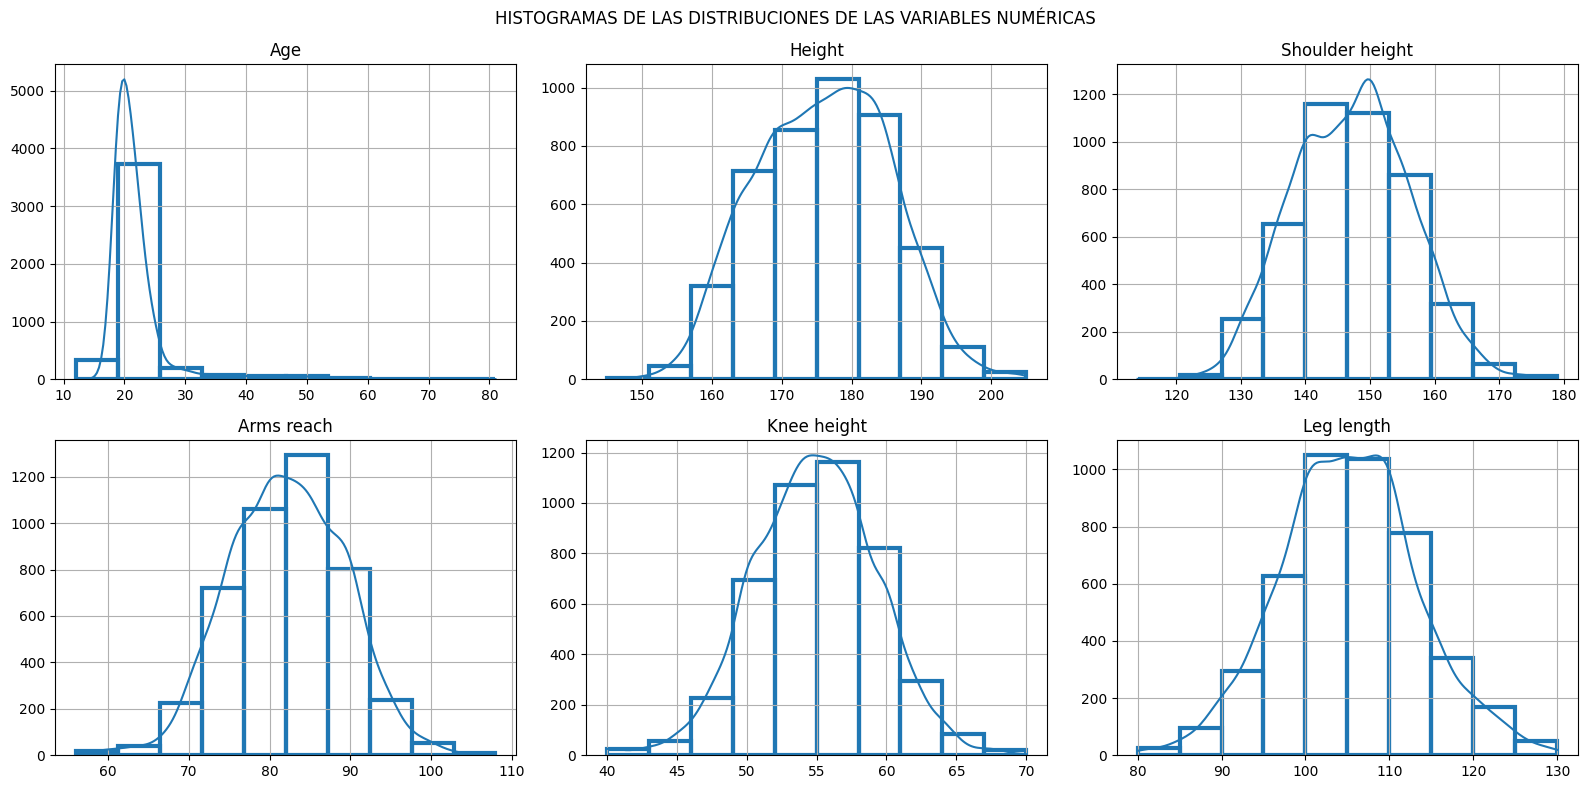

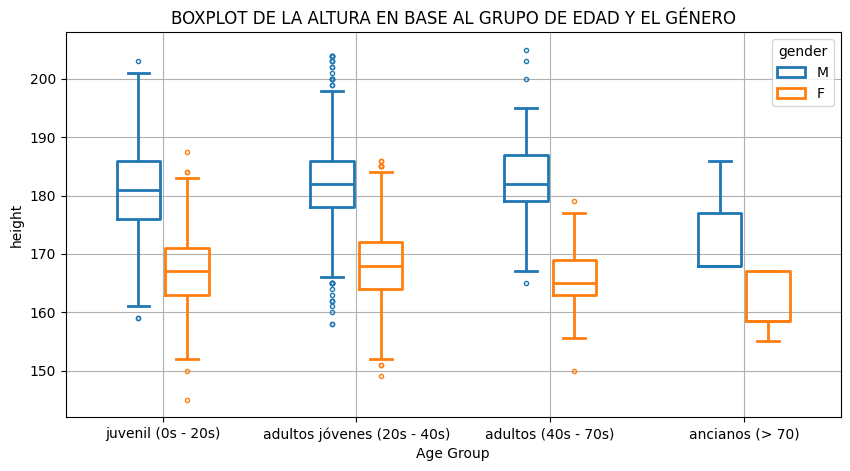

In [466]:
# ------------------------------------------------------------------------------------------------------
# DISTRIBUCIONES
# ------------------------------------------------------------------------------------------------------

# Histogramas de todas las variables numéricas
# Boxplots de la variable objetivo, segmentados por cada variable categórica.
# Detección y tratamiento de outliers (método IQR o Z-score; justifica cuál usas).

df['age_group'] = [set_age_group(age) for age in  df['age']]

def plot_density(data: pd.DataFrame, hist_bins = 10):
    numeric_data = data.select_dtypes(include=['number'])
    n = len(numeric_data.columns)
    fig, axes = plt.subplots(2, int(n/2), figsize = (16, 8))
    axes = axes.flatten()
    
    for column, ax in zip(numeric_data.columns, axes):
        sns.histplot(data = data, x = column, kde=True, bins=hist_bins, ax=ax, fill = False, linewidth = 3,edgecolor = 'steelblue')
        ax.set_title(column.replace('_', ' ').capitalize())
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.grid()
    
    plt.suptitle('HISTOGRAMAS DE LAS DISTRIBUCIONES DE LAS VARIABLES NUMÉRICAS')
    plt.tight_layout()
    plt.savefig("output\\ej1_histogramas.png")
    plt.show()


def plot_boxplot(data: pd.DataFrame, column: str):

    plt.figure(figsize = (10,5))
    sns.boxplot(x = df['age_group'], y = df[column], hue = df['gender'], fill=False, gap=.1, width=0.5, fliersize=3, linewidth = 2)
    plt.xlabel('Age Group')
    plt.ylabel(column.replace('_', ' '))
    plt.grid()
        
    plt.title('BOXPLOT DE LA ALTURA EN BASE AL GRUPO DE EDAD Y EL GÉNERO')

    plt.show()
        

plot_density(df)
plot_boxplot(df, 'height')

,Absoluta,Relativa
M,2638,59.12147
F,1824,40.87853


,Absoluta,Relativa
ancianos (> 70),8,0.179292
juvenil (0s - 20s),1321,29.605558
adultos (40s - 70s),128,2.868669
adultos jóvenes (20s - 40s),3005,67.346481


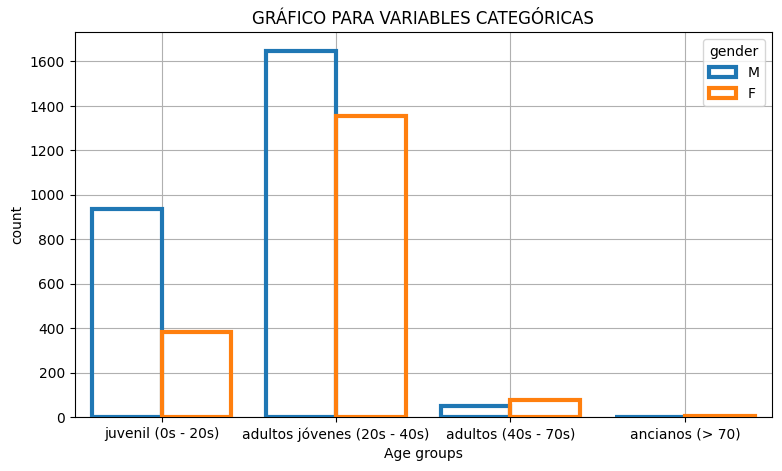

In [467]:
# ------------------------------------------------------------------------------------------------------
# VARIABLES CATEGÓRICAS
# ------------------------------------------------------------------------------------------------------

# Frecuencia absoluta y relativa de cada categoría.
# Gráfico de barras o de sectores para cada variable categórica.
# Análisis de si alguna categoría domina el dataset (desbalance).

def frecuencias(data: pd.DataFrame, column: str) -> pd.DataFrame:
    n = len(data[column])

    freq = pd.DataFrame({})
    freq['Absoluta'] = [list(data[column]).count(element) for element in set(data[column])]
    freq['Relativa'] = 100 * freq['Absoluta'] / n

    freq.index = set(data[column])

    return freq

display(frecuencias(df, 'gender'))
display(frecuencias(df, 'age_group'))


def plot_barras(data: pd.DataFrame):
    plt.figure(figsize = (9, 5))
    sns.countplot(data=df, x='age_group', hue='gender', linewidth = 3, zorder = 3, fill = False)
    plt.xlabel('Age groups')
    plt.ylabel('count')
    plt.grid()
    plt.title('GRÁFICO PARA VARIABLES CATEGÓRICAS')
    plt.show()

plot_barras(df)



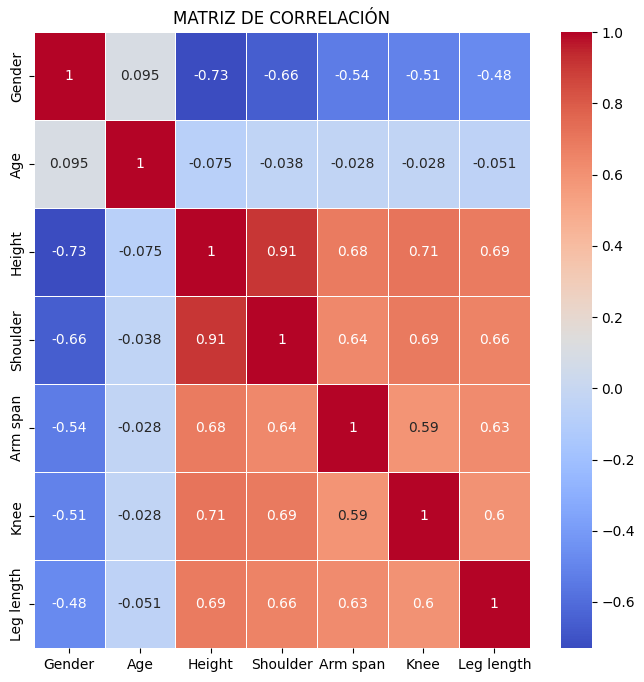

In [468]:
# ------------------------------------------------------------------------------------------------------
# CORRELACIONES
# ------------------------------------------------------------------------------------------------------

# Mapa de calor (heatmap) de la matriz de correlaciones de Pearson de las variables numéricas.
# Identificación de las tres variables con mayor correlación (en valor absoluto) con la variable objetivo.
# Detección de posible multicolinealidad entre predictoras (pares con |r| > 0,9).

def heatmap(data: pd.DataFrame):
    data['gender'] = data['gender'].map({'M': 0, 'F': 1})
    data = data.drop(['age_group'], axis = 1)
    data.columns = ['Gender', 'Age', 'Height', 'Shoulder', 'Arm span', 'Knee', 'Leg length']
    plt.figure(figsize = (8, 8))
    sns.heatmap(data.corr(), annot=True, linewidths=0.5, cmap = 'coolwarm')
    plt.title('MATRIZ DE CORRELACIÓN')
    plt.show()

heatmap(df)